In [ ]:
!pip install fastapi uvicorn scikit-learn nest_asyncio

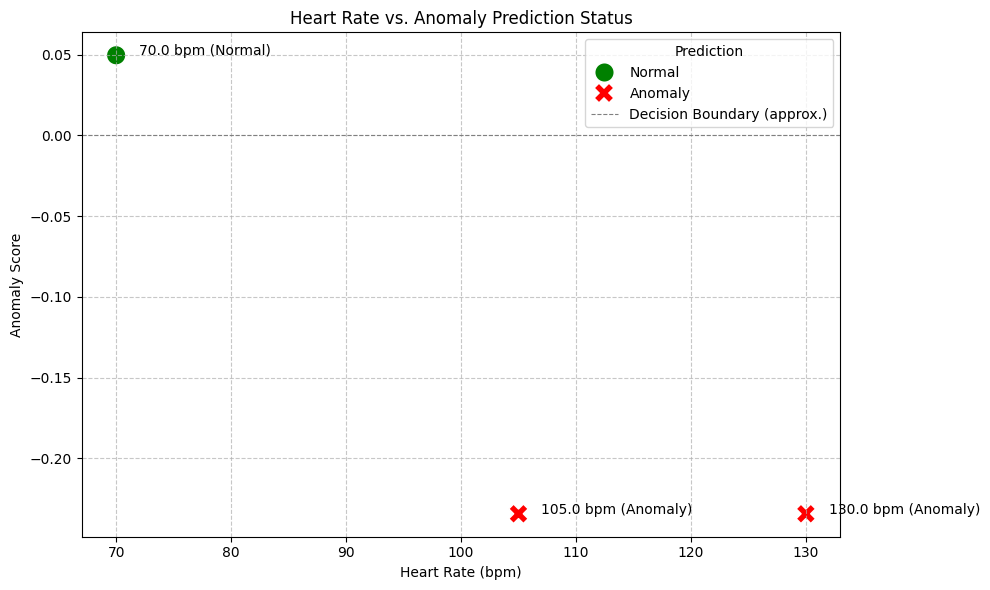

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data from the previous API calls (hardcoded for demonstration)
heart_rates_data = [
    {'heart_rate': 70.0, 'anomaly_prediction': 'Normal', 'anomaly_score': 0.04960411483345639},
    {'heart_rate': 105.0, 'anomaly_prediction': 'Anomaly', 'anomaly_score': -0.23424068949299282},
    {'heart_rate': 130.0, 'anomaly_prediction': 'Anomaly', 'anomaly_score': -0.23424068949299282}
]

# Convert to DataFrame
df_predictions = pd.DataFrame(heart_rates_data)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_predictions,
    x='heart_rate',
    y='anomaly_score',
    hue='anomaly_prediction',
    style='anomaly_prediction',
    s=200, # size of points
    palette={'Normal': 'green', 'Anomaly': 'red'}
)

# Add labels to the points
for i, row in df_predictions.iterrows():
    plt.text(row['heart_rate'] + 2, row['anomaly_score'], f"{row['heart_rate']} bpm ({row['anomaly_prediction']})")

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, label='Decision Boundary (approx.)')

plt.title('Heart Rate vs. Anomaly Prediction Status')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Anomaly Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Prediction')
plt.tight_layout()
plt.show()

In [ ]:
import requests
import json

# Base URL for the FastAPI service
base_url = "http://0.0.0.0:8001"
predict_endpoint = f"{base_url}/predict"

# Test with a normal heart rate
normal_hr = 70.0
response_normal = requests.post(predict_endpoint, json={"heart_rate": normal_hr})
print(f"Prediction for {normal_hr} bpm: {response_normal.json()}")

# Test with a slightly high heart rate (might be normal depending on individual)
slightly_high_hr = 105.0
response_slightly_high = requests.post(predict_endpoint, json={"heart_rate": slightly_high_hr})
print(f"Prediction for {slightly_high_hr} bpm: {response_slightly_high.json()}")

# Test with an anomalous heart rate
anomaly_hr = 130.0
response_anomaly = requests.post(predict_endpoint, json={"heart_rate": anomaly_hr})
print(f"Prediction for {anomaly_hr} bpm: {response_anomaly.json()}")

INFO:     127.0.0.1:38758 - "POST /predict HTTP/1.1" 200 OK
Prediction for 70.0 bpm: {'heart_rate': 70.0, 'anomaly_prediction': 'Normal', 'anomaly_score': 0.04960411483345639}
INFO:     127.0.0.1:38768 - "POST /predict HTTP/1.1" 200 OK
Prediction for 105.0 bpm: {'heart_rate': 105.0, 'anomaly_prediction': 'Anomaly', 'anomaly_score': -0.23424068949299282}
INFO:     127.0.0.1:38780 - "POST /predict HTTP/1.1" 200 OK
Prediction for 130.0 bpm: {'heart_rate': 130.0, 'anomaly_prediction': 'Anomaly', 'anomaly_score': -0.23424068949299282}


In [ ]:
import joblib
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn
import nest_asyncio
import threading
import asyncio
import time
import os
import signal
import subprocess

# Load the trained Isolation Forest model
model = joblib.load('model.pkl')

# Initialize FastAPI app
app = FastAPI()

# Define request body model
class HeartRateData(BaseModel):
    heart_rate: float

# Define prediction endpoint
@app.post('/predict')
async def predict_anomaly(data: HeartRateData):
    hr = data.heart_rate
    # Reshape for model input
    prediction = model.predict([[hr]])[0]
    score = model.decision_function([[hr]])[0]

    # -1 indicates anomaly, 1 indicates normal
    status = 'Anomaly' if prediction == -1 else 'Normal'

    return {
        'heart_rate': hr,
        'anomaly_prediction': status,
        'anomaly_score': score
    }

# Function to run FastAPI app in a separate thread
def run_fastapi_app():
    nest_asyncio.apply()
    config = uvicorn.Config(app, host="0.0.0.0", port=8001, log_level="info")
    server = uvicorn.Server(config)
    try:
        asyncio.run(server.serve())
    except OSError as e:
        if e.errno == 98:
            print(f"ERROR: Port 8001 is already in use. Please stop any running process using this port, or restart the Colab runtime.")
        else:
            raise e

# Start the FastAPI app in a new thread
if __name__ == "__main__":
    # Ensure any previous instances on port 8001 are stopped using lsof and kill
    try:
        # Find PIDs using port 8001
        result = subprocess.run(['lsof', '-t', '-i:8001'], capture_output=True, text=True, check=False)
        pids_output = result.stdout.strip()

        if pids_output:
            pids = pids_output.split('\n')
            for pid_str in pids:
                try:
                    pid = int(pid_str)
                    os.kill(pid, signal.SIGKILL)
                    print(f"Killed process {pid} using port 8001.")
                except (ValueError, ProcessLookupError):
                    print(f"Could not kill process {pid_str}, might be already gone or invalid PID.")
            time.sleep(3) # Give more time for the port to clear after killing processes
        else:
            print("No process found using port 8001.")
    except FileNotFoundError:
        print("lsof command not found. Cannot automatically clear port. Please ensure no other process is using port 8001.")
    except Exception as e:
        print(f"An error occurred while attempting to clear port 8001: {e}")

    # Check if the server is already running to prevent multiple instances
    if not any(thread.name == "uvicorn_thread" for thread in threading.enumerate()):
        uvicorn_thread = threading.Thread(target=run_fastapi_app, name="uvicorn_thread")
        uvicorn_thread.start()
        print("FastAPI app started in a separate thread on http://0.0.0.0:8001")
    else:
        print("FastAPI app is already running.")

    # Give the server a moment to start up
    time.sleep(2)
    print("Server should be ready.")

INFO:     Started server process [5210]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8001 (Press CTRL+C to quit)


No process found using port 8001.
FastAPI app started in a separate thread on http://0.0.0.0:8001
Server should be ready.


In [ ]:
import numpy as np
from sklearn.ensemble import IsolationForest
import joblib

# Generate sample heart rate data (normal range: 60–100)
np.random.seed(42)
normal_data = np.random.normal(loc=75, scale=8, size=200)

# Reshape for model
X = normal_data.reshape(-1, 1)

# Train Isolation Forest
model = IsolationForest(contamination=0.1)
model.fit(X)

# Save model
joblib.dump(model, "model.pkl")

print("Model trained and saved!")

Model trained and saved!
